## L'Eua Claire
### Fecal Coliform (Phannet)
## Group 5
## Team Members
| Name | Student's ID |
|---|---|
| Rith Theary | e20231141 |
| Roeurn Phannet | e20230799 |
| Meth Sreyka | e20230172 |

> **Goal:** Train 5 regression models then compare with 5-Fold CV next predict Fecal Coliform then  
> classify water as **Safe / Not Safe** (threshold = 50 MPN/100 mL).


## Imports

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, classification_report, confusion_matrix)
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)
print("Libraries loaded.")
from sklearn.preprocessing import QuantileTransformer

Libraries loaded.


In [35]:
import os

file_path = r"D:\mini_water_predict\Dataset\water_quality_cleandataversion.csv"

print(os.path.exists(file_path))

True


## Load Cleaned Data

In [36]:
df = pd.read_csv(r"D:\mini_water_predict\Dataset\water_quality_cleandataversion.csv")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()

Loaded: 2,617 rows × 23 columns
Columns: ['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'DO', 'pH', 'Conductivity', 'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform', 'Total_Coliform', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'Total_Coliform_log', 'Fecal_Coliform_log', 'DO_sqrt', 'BOD_Temp', 'BOD_Conductivity', 'Nitrate_Temp', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Is_Monsoon']


,Water_Body_Type,State_Name,Year,Temperature,DO,pH,Conductivity,BOD,Nitrate_Nitrite,Fecal_Coliform,...,Nitrate_Nitrite_log,Total_Coliform_log,Fecal_Coliform_log,DO_sqrt,BOD_Temp,BOD_Conductivity,Nitrate_Temp,BOD_Temp_log,BOD_Conductivity_log,Is_Monsoon
0,LAKE,ANDHRA PRADESH,2017,26.0000,6.3500,7.6500,815.5000,1.8000,2.2600,20.0000,...,1.1817,7.2269,3.0445,2.5199,46.8000,1467.9000,58.7600,3.8670,7.2923,1
1,LAKE,ASSAM,2017,23.5000,4.7000,6.6000,89.0000,8.6000,0.9000,1150.0000,...,0.6419,8.1259,7.0484,2.1679,202.1000,765.4000,21.1500,5.3137,6.6417,1
2,LAKE,ASSAM,2017,29.0000,5.5500,7.2000,103.5000,1.8500,0.7500,750.0000,...,0.5596,7.9377,6.6214,2.3558,53.6500,191.4750,21.7500,4.0009,5.2600,1
3,POND,ASSAM,2017,28.0000,2.6500,7.6000,617.5000,9.6000,3.2500,2300.0000,...,1.4469,9.2934,7.7411,1.6279,268.8000,5928.0000,91.0000,5.5977,8.6876,1
4,POND,ASSAM,2017,27.5000,5.1500,6.7000,130.5000,10.1500,1.2000,1200.0000,...,0.7885,9.5943,7.0909,2.2694,279.1250,1324.5750,33.0000,5.6352,7.1896,1


## Feature Selection & Encoding

**Column contract (must match EDA output):**

| Feature | Column used in model |
|---|---|
| Temperature | `Temperature` |
| Dissolved Oxygen | `DO_sqrt` |
| pH | `pH` |
| Conductivity | `Conductivity_log` |
| BOD | `BOD_log` |
| Nitrate/Nitrite | `Nitrate_Nitrite_log` |
| Water body type | One-hot from `Water_Body_Type` |
| State | Frequency-encoded from `State_Name` |

**No winsorizing done once in EDA.**

In [37]:
df.columns

Index(['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'DO', 'pH',
       'Conductivity', 'BOD', 'Nitrate_Nitrite', 'Fecal_Coliform',
       'Total_Coliform', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log',
       'Total_Coliform_log', 'Fecal_Coliform_log', 'DO_sqrt', 'BOD_Temp',
       'BOD_Conductivity', 'Nitrate_Temp', 'BOD_Temp_log',
       'BOD_Conductivity_log', 'Is_Monsoon'],
      dtype='object')

In [38]:
# Drop leakage and non-feature columns
DROP_COLS = ['Total_Coliform', 'Total_Coliform_log',
             'Fecal_Coliform_log',           # log of target not a feature
             'DO',                            # raw version; using DO_sqrt
             'Conductivity', 'BOD', 'Nitrate_Nitrite',  # raw; using _log versions
             'State_WaterType', 'Is_Monsoon']               # composite label, not a feature
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True, errors='ignore')
print("After dropping leakage/redundant columns:")
print(df.columns.tolist())

After dropping leakage/redundant columns:
['Water_Body_Type', 'State_Name', 'Year', 'Temperature', 'pH', 'Fecal_Coliform', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'DO_sqrt', 'BOD_Temp', 'BOD_Conductivity', 'Nitrate_Temp', 'BOD_Temp_log', 'BOD_Conductivity_log']


In [48]:
# Validate that all required feature columns exist
REQUIRED_FEATURES = ['Temperature', 'DO_sqrt', 'pH',
                     'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log']

missing = [c for c in REQUIRED_FEATURES if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns check EDA notebook output: {missing}")
else:
    print("All required feature columns present.")
    print(REQUIRED_FEATURES)

All required feature columns present.
['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log']


In [49]:
# One-hot encode Water_Body_Type
if 'Water_Body_Type' in df.columns:
    df = pd.get_dummies(df, columns=['Water_Body_Type'], drop_first=True)
    wb_dummies = [c for c in df.columns if c.startswith('Water_Body_Type_')]
    print("Water body dummies created:", wb_dummies)
else:
    wb_dummies = []
    print("Water_Body_Type column not found skipping one-hot encoding.")

HAS_STATE = 'State_Name' in df.columns
extra_cols = wb_dummies + (['State_freq'] if HAS_STATE else [])

FEATURE_COLS = REQUIRED_FEATURES + extra_cols
NEW_FEATURES = ['BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp', 'Is_Monsoon']
for f in NEW_FEATURES:
    if f in df.columns:
        FEATURE_COLS.append(f)
print("\nFinal feature list:", FEATURE_COLS)

Water_Body_Type column not found skipping one-hot encoding.

Final feature list: ['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp']


## Define X and y

In [51]:
TARGET = 'Fecal_Coliform'

FEATURE_COLS_PRE_SPLIT = [c for c in FEATURE_COLS if c != 'State_freq']
X = df[FEATURE_COLS_PRE_SPLIT].copy()
if HAS_STATE:
    X['State_Name_raw'] = df['State_Name']
y_raw = df[TARGET].copy()

print(f"Features : {len(FEATURE_COLS)}")
print(f"X shape  : {X.shape}")
print(f"y (raw)  : min={y_raw.min():.1f}  max={y_raw.max():.1f}  median={y_raw.median():.1f}")
print(f"y skew   : {y_raw.skew():.3f}")

Features : 9
X shape  : (2617, 9)
y (raw)  : min=1.0  max=1779500.0  median=250.0
y skew   : 7.442


## Train/Test Split + K-Fold Setup

In [52]:
X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.2, random_state=42
)

if HAS_STATE:
    state_freq_map = X_train['State_Name_raw'].value_counts(normalize=True)
    fallback_freq = state_freq_map.min()
    X_train['State_freq'] = X_train['State_Name_raw'].map(state_freq_map)
    X_test['State_freq']  = X_test['State_Name_raw'].map(state_freq_map).fillna(fallback_freq)
    X_train.drop(columns=['State_Name_raw'], inplace=True)
    X_test.drop(columns=['State_Name_raw'], inplace=True)
    X_train = X_train[FEATURE_COLS]
    X_test  = X_test[FEATURE_COLS]

# Fit QuantileTransformer on TRAIN target only this is the leakage fix
qt = QuantileTransformer(output_distribution='normal', random_state=42)
y_train = qt.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten()
y_test  = qt.transform(y_test_raw.values.reshape(-1, 1)).flatten()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"Train : {X_train.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")

Train : 2,093 rows
Test  : 524 rows


## Define 4 Models

In [53]:
MODELS = {
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=500, max_depth=None, min_samples_split=2,
        random_state=42, n_jobs=-1),

    "Random Forest": RandomForestRegressor(
        n_estimators=400, random_state=42, n_jobs=-1),

    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=8,
        random_state=42, verbosity=0),

    "CatBoost": CatBoostRegressor(
        iterations=400, learning_rate=0.05, depth=8,
        random_seed=42, verbose=0),
}
for name in MODELS: print(f" • {name}")


 • Extra Trees
 • Random Forest
 • XGBoost
 • CatBoost


## 5-Fold Cross-Validation + Hold-out Test

In [ ]:
def fit_and_evaluate(model, X_tr, y_tr, X_te, y_te_raw):
    """Train on QuantileTransformer-normalized scale, predict, convert back
    to original scale via qt.inverse_transform, return metrics."""
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_te)
    pred_raw = qt.inverse_transform(pred_log.reshape(-1, 1)).flatten().clip(0)
    mae  = mean_absolute_error(y_te_raw, pred_raw)
    rmse = np.sqrt(mean_squared_error(y_te_raw, pred_raw))
    r2   = r2_score(y_te_raw, pred_raw)
    return pred_raw, mae, rmse, r2


cv_summary   = {}
test_results = []
fitted       = {}

print("Running 5-Fold CV...\n")
print(f"{'Model':<22} {'CV RMSE mean':>14} {'CV RMSE std':>12} {'CV R² mean':>12}")

for name, model in MODELS.items():
    cv_rmse = cross_val_score(model, X_train, y_train, cv=kf,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
    cv_r2   = cross_val_score(model, X_train, y_train, cv=kf,
                               scoring='r2', n_jobs=-1)
    cv_summary[name] = {'CV RMSE mean': (-cv_rmse).mean(),
                        'CV RMSE std':  (-cv_rmse).std(),
                        'CV R² mean':   cv_r2.mean()}

    preds, mae, rmse, r2 = fit_and_evaluate(
        model, X_train, y_train, X_test, y_test_raw)
    fitted[name] = (model, preds)
    test_results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})

    print(f"{name:<22} {(-cv_rmse).mean():>14.4f} {(-cv_rmse).std():>12.4f} {cv_r2.mean():>12.4f}")

print("\n Cross-validation complete.")

Running 5-Fold CV...

Model                    CV RMSE mean  CV RMSE std   CV R² mean
Extra Trees                    0.6704       0.0200       0.5688
Random Forest                  0.6775       0.0245       0.5597
XGBoost                        0.6911       0.0244       0.5416
CatBoost                       0.6666       0.0162       0.5735

 Cross-validation complete.


    Fits on the log1p target, but evaluates metrics on the ORIGINAL
    (raw MPN/100mL) scale by inverse-transforming predictions first.
    This keeps reported MAE/RMSE/R² meaningful in real units, while
    still letting the model train on the better-behaved log target.

## Results Table

In [55]:
results_df = pd.DataFrame(test_results).sort_values('R²', ascending=False).reset_index(drop=True)

print("FINAL RESULTS, Hold-out Test Set (Original Scale)")
print(results_df.to_string(index=False))

# Best model = highest R² (primary metric for regression quality)
best_row  = results_df.iloc[0]
BEST_NAME = best_row['Model']
print(f"\n BEST MODEL : {BEST_NAME}  (selected by R²)")
print(f"   MAE  = {best_row['MAE']:,.2f}")
print(f"   RMSE = {best_row['RMSE']:,.2f}")
print(f"   R²   = {best_row['R²']:.4f}")


FINAL RESULTS, Hold-out Test Set (Original Scale)
        Model        MAE        RMSE     R²
      XGBoost 23328.6189  99896.5367 0.2566
  Extra Trees 23220.0856 100345.4240 0.2499
Random Forest 23059.5056 100386.8671 0.2493
     CatBoost 23277.1026 103174.3034 0.2070

 BEST MODEL : XGBoost  (selected by R²)
   MAE  = 23,328.62
   RMSE = 99,896.54
   R²   = 0.2566


## Model Comparison Chart

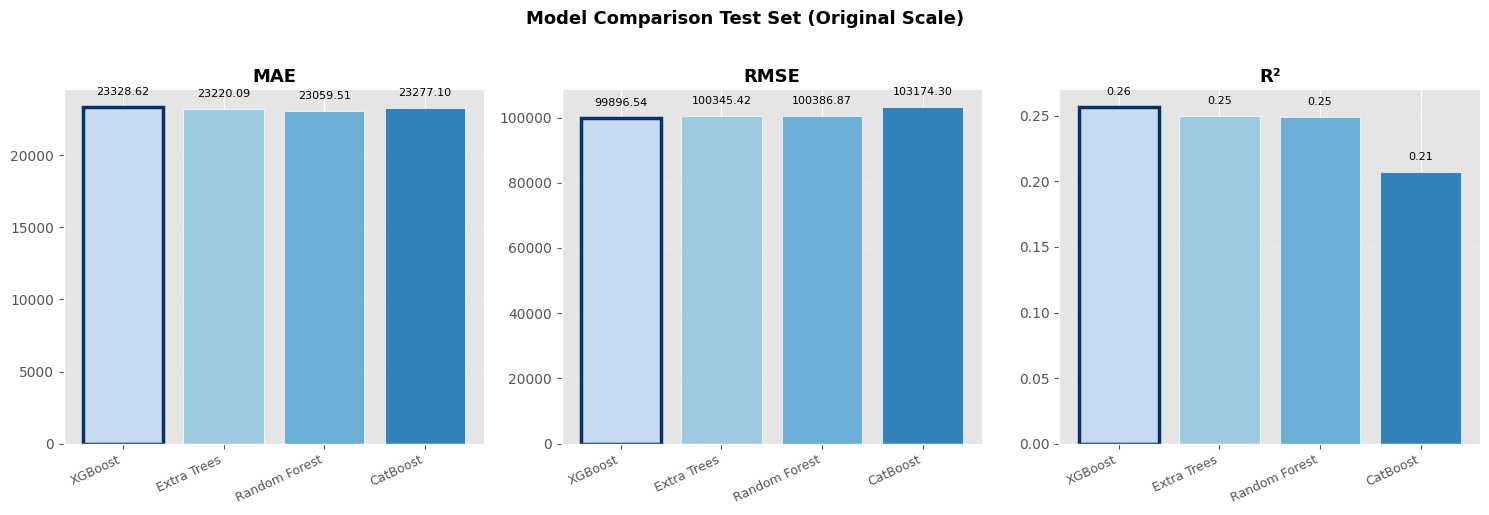

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

palette = [
    "#c6dbef", "#9ecae1", "#6baed6",
    "#3182bd", "#08519c"
]

best_idx = results_df['R²'].values.argmax()

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = results_df[metric]
    names = results_df['Model']

    bars = ax.bar(names, vals, color=palette, edgecolor='white')

    # highlight best model (by R²)
    bars[best_idx].set_edgecolor('#08306b')
    bars[best_idx].set_linewidth(2.5)

    offset = vals.max() * 0.03

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + offset,
            f'{val:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=25, ha='right', fontsize=9)

    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Model Comparison Test Set (Original Scale)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()

## Train Best Model on Full Data & Save

In [57]:
print(f"Training {BEST_NAME} on full dataset...")
best_model = MODELS[BEST_NAME]
best_model.fit(X, y)

joblib.dump(best_model,  'best_model.pkl')
joblib.dump(FEATURE_COLS,'feature_cols.pkl')

print(f" best_model.pkl saved")
print(f" feature_cols.pkl saved")
print(f"  Features: {FEATURE_COLS}")

Training XGBoost on full dataset...
 best_model.pkl saved
 feature_cols.pkl saved
  Features: ['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp']


## Predictions + Safe / Not Safe Classification

| Threshold | Label |
|---|---|
| Fecal Coliform ≤ 50 MPN/100 mL |  Safe |
| Fecal Coliform > 50 MPN/100 mL |  Not Safe |

    fitted[BEST_NAME] now stores (model, preds_raw) where preds_raw was already inverse-transformed (expm1) back to original MPN/100mL scale inside fit_and_evaluate()

In [58]:
SAFE_THRESHOLD = 50   # MPN / 100 mL

best_fitted, pred_raw = fitted[BEST_NAME]

pred_label   = pd.Series(pred_raw).apply(lambda x: 'Safe' if x <= SAFE_THRESHOLD else 'Not Safe')
actual_label = y_test_raw.apply(lambda x: 'Safe' if x <= SAFE_THRESHOLD else 'Not Safe')

sample = pd.DataFrame({
    'Actual FC (MPN)'     : y_test_raw.values[:10].round(2),
    'Predicted FC (MPN)'  : pred_raw[:10].round(2),
    'Actual Label'        : actual_label.values[:10],
    'Predicted Label'     : pred_label.values[:10],
})
print("Sample predictions (first 10):")
print(sample.to_string(index=False))

Sample predictions (first 10):
 Actual FC (MPN)  Predicted FC (MPN) Actual Label Predicted Label
         17.5000             40.0000         Safe            Safe
         57.0000            455.1200     Not Safe        Not Safe
        220.0000          31680.5391     Not Safe        Not Safe
        605.0000            399.9100     Not Safe        Not Safe
         27.5000            219.7200         Safe        Not Safe
      14350.0000            700.0000     Not Safe        Not Safe
      20042.0000         254406.9219     Not Safe        Not Safe
      23850.0000          47024.8789     Not Safe        Not Safe
       1650.0000            923.3700     Not Safe        Not Safe
         13.5000             40.0000         Safe            Safe


## Classification Report + Confusion Matrix

CLASSIFICATION REPORT (Safe vs Not Safe)
              precision    recall  f1-score   support

    Not Safe       0.84      0.86      0.85       352
        Safe       0.70      0.66      0.68       172

    accuracy                           0.80       524
   macro avg       0.77      0.76      0.76       524
weighted avg       0.79      0.80      0.79       524



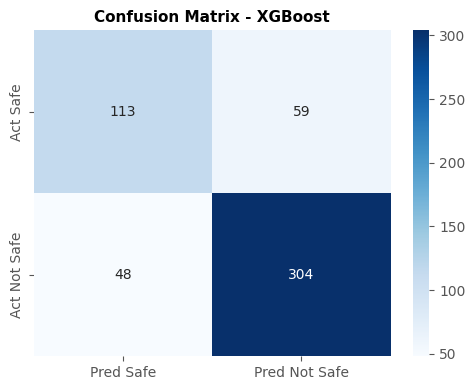

In [59]:
print("CLASSIFICATION REPORT (Safe vs Not Safe)")
print(classification_report(actual_label, pred_label, target_names=['Not Safe','Safe']))

cm = confusion_matrix(actual_label, pred_label, labels=['Safe','Not Safe'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Safe','Pred Not Safe'],
            yticklabels=['Act Safe', 'Act Not Safe'], ax=ax)
ax.set_title(f'Confusion Matrix - {BEST_NAME}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Importance

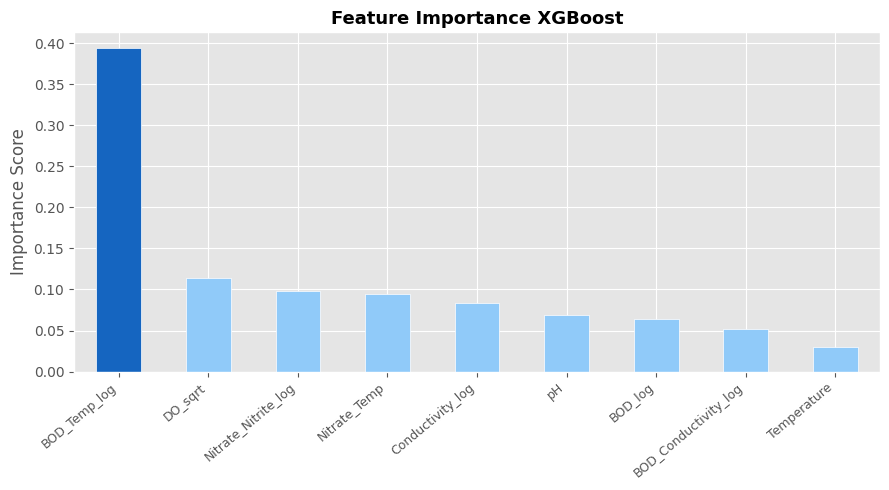

Saved feature_importance.png

Top features:
BOD_Temp_log          0.3938
DO_sqrt               0.1145
Nitrate_Nitrite_log   0.0980
Nitrate_Temp          0.0943
Conductivity_log      0.0833


In [60]:
if hasattr(best_fitted, 'feature_importances_'):
    importances = pd.Series(best_fitted.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(importances))]
    importances.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'Feature Importance {BEST_NAME}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Importance Score')
    ax.set_xticklabels(importances.index, rotation=40, ha='right', fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show();  print("Saved feature_importance.png")
    print("\nTop features:")
    print(importances.head().to_string())
else:
    print(f"{BEST_NAME} does not expose feature_importances_")

## Actual vs Predicted Plot

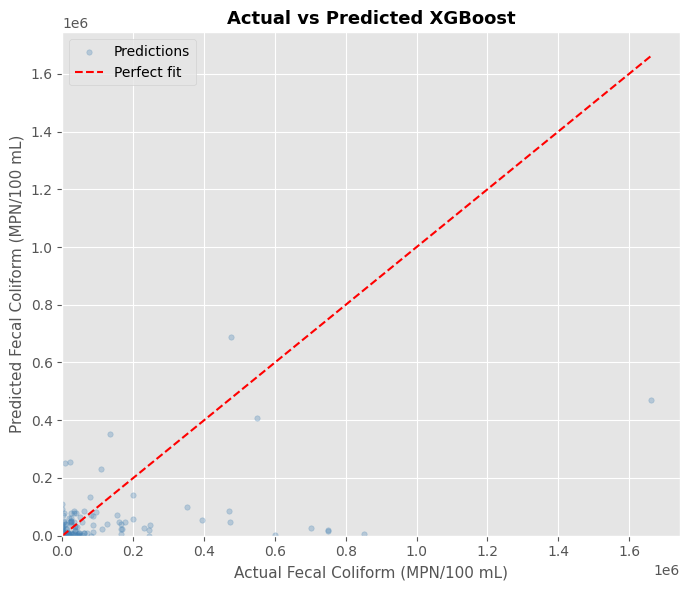

Saved actual_vs_predicted.png


In [61]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_raw, pred_raw, alpha=0.3, s=15, color='steelblue', label='Predictions')
max_v = max(float(y_test_raw.max()), float(pred_raw.max()))
ax.plot([0, max_v], [0, max_v], 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Fecal Coliform (MPN/100 mL)', fontsize=11)
ax.set_ylabel('Predicted Fecal Coliform (MPN/100 mL)', fontsize=11)
ax.set_title(f'Actual vs Predicted {BEST_NAME}', fontsize=13, fontweight='bold')
ax.legend();  ax.set_xlim(left=0);  ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show();  print("Saved actual_vs_predicted.png")

## Hyperparameter Tuning Extra Trees (RandomizedSearchCV)

> Runs 50 random combinations × 5-fold CV on the **training set only**.  
> Best params are then evaluated on the **hold-out test set**.


In [64]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(300, 800),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 5)
}

base_xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=50,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

search.fit(X_train, y_train)

print("\nBEST PARAMETERS")
for k, v in search.best_params_.items():
    print(f"{k:<20}: {v}")

print(f"\nBest CV R² (QuantileTransformer-space): {search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

BEST PARAMETERS
colsample_bytree    : 0.7755885682822544
gamma               : 0.3922819067113298
learning_rate       : 0.017351715590482677
max_depth           : 7
min_child_weight    : 7
n_estimators        : 426
subsample           : 0.8783896824374792

Best CV R² (QuantileTransformer-space): 0.5559


In [65]:
# Evaluate tuned model on hold-out test set
tuned_xgb = search.best_estimator_

pred_qt_tuned  = tuned_xgb.predict(X_test)
pred_raw_tuned = qt.inverse_transform(pred_qt_tuned.reshape(-1, 1)).flatten().clip(0)

mae_t  = mean_absolute_error(y_test_raw, pred_raw_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test_raw, pred_raw_tuned))
r2_t   = r2_score(y_test_raw, pred_raw_tuned)

print(" XGBOOST, Hold-out Test Set ")
print(f"  MAE  : {mae_t:,.2f}")
print(f"  RMSE : {rmse_t:,.2f}")
print(f"  R²   : {r2_t:.4f}")

# Compare with baseline XGBoost
baseline = results_df[results_df['Model'] == 'XGBoost'].iloc[0]
print("\n IMPROVEMENT")
print(f"  R²   : {baseline['R²']:.4f}  to  {r2_t:.4f}  (Δ {r2_t - baseline['R²']:+.4f})")
print(f"  MAE  : {baseline['MAE']:,.1f}  to  {mae_t:,.1f}  (Δ {mae_t - baseline['MAE']:+,.1f})")
print(f"  RMSE : {baseline['RMSE']:,.1f}  to  {rmse_t:,.1f}  (Δ {rmse_t - baseline['RMSE']:+,.1f})")

 XGBOOST, Hold-out Test Set 
  MAE  : 23,109.61
  RMSE : 103,722.09
  R²   : 0.1986

 IMPROVEMENT
  R²   : 0.2566  to  0.1986  (Δ -0.0580)
  MAE  : 23,328.6  to  23,109.6  (Δ -219.0)
  RMSE : 99,896.5  to  103,722.1  (Δ +3,825.6)


In [66]:
# Save tuned model
joblib.dump(tuned_xgb,    'best_model_tuned.pkl')
joblib.dump(qt,           'quantile_transformer.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')
print("Saved: best_model_tuned.pkl")
print("Saved: quantile_transformer.pkl")
print(f"Features: {FEATURE_COLS}")
print("IMPORTANT: this model predicts in QuantileTransformer-space.")
print("Apply qt.inverse_transform(prediction.reshape(-1,1)).flatten().clip(0)")
print("to get MPN/100mL when using it later.")

Saved: best_model_tuned.pkl
Saved: quantile_transformer.pkl
Features: ['Temperature', 'DO_sqrt', 'pH', 'Conductivity_log', 'BOD_log', 'Nitrate_Nitrite_log', 'BOD_Temp_log', 'BOD_Conductivity_log', 'Nitrate_Temp']
IMPORTANT: this model predicts in QuantileTransformer-space.
Apply qt.inverse_transform(prediction.reshape(-1,1)).flatten().clip(0)
to get MPN/100mL when using it later.


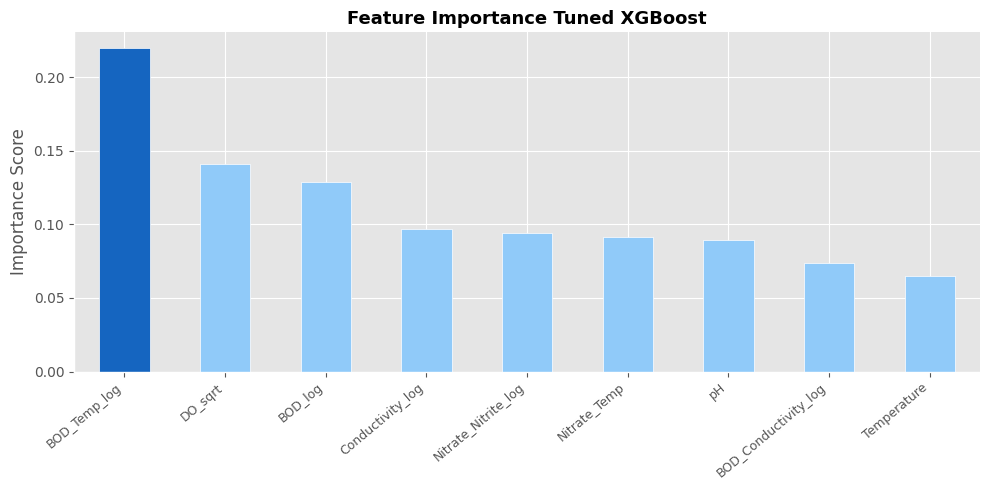

Top 5 features:
BOD_Temp_log          0.2195
DO_sqrt               0.1408
BOD_log               0.1288
Conductivity_log      0.0971
Nitrate_Nitrite_log   0.0939


In [67]:
# Feature importance(tuned model)
importances = pd.Series(tuned_xgb.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1565C0' if i == 0 else '#90CAF9' for i in range(len(importances))]
importances.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance Tuned XGBoost', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.set_xticklabels(importances.index, rotation=40, ha='right', fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance_tuned.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top 5 features:")
print(importances.head().to_string())


## Pipeline Summary

| Step | Status |
|---|---|
| Load cleaned data (no re-cleaning) | Done |
| Validate required columns exist | Done |
| Encode Water_Body_Type + State_Name | Done |
| Train on log1p(Fecal_Coliform) | Done |
| 5-Fold CV on 4 models | Done |
| Report metrics in original scale | Done |
| Best model saved (.pkl) | Done |
| Safe / Not Safe (threshold = 50) | Done |
| Classification report + confusion matrix | Done |
| Feature importance chart | Done |

In [68]:
# 1. Check target distribution
print("Target (Fecal_Coliform) Statistics:")
print(y_raw.describe())
print("\nSkewness:", y_raw.skew())

# 2. Correlation with target
corr_with_target = X.corrwith(y_raw).sort_values(ascending=False)
print("\nTop correlations with Fecal_Coliform:")
print(corr_with_target.head(10))

Target (Fecal_Coliform) Statistics:
count      2617.0000
mean      26339.8403
std      109779.0425
min           1.0000
25%          30.0000
50%         250.0000
75%        3100.0000
max     1779500.0000
Name: Fecal_Coliform, dtype: float64

Skewness: 7.442072233025938

Top correlations with Fecal_Coliform:
BOD_log                 0.3059
BOD_Temp_log            0.2971
BOD_Conductivity_log    0.2506
Conductivity_log        0.1512
Nitrate_Nitrite_log     0.1273
Temperature             0.0973
Nitrate_Temp            0.0660
DO_sqrt                -0.0658
pH                     -0.0854
dtype: float64
